In [1]:
!apt-get install -y libspatialindex-dev
!pip install geopandas shapely fiona pyproj rtree


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libspatialindex-c6 libspatialindex6
The following NEW packages will be installed:
  libspatialindex-c6 libspatialindex-dev libspatialindex6
0 upgraded, 3 newly installed, 0 to remove and 2 not upgraded.
Need to get 319 kB of archives.
After this operation, 1,416 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libspatialindex6 amd64 1.9.3-2 [247 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libspatialindex-c6 amd64 1.9.3-2 [55.8 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libspatialindex-dev amd64 1.9.3-2 [16.0 kB]
Fetched 319 kB in 1s (456 kB/s)
Selecting previously unselected package libspatialindex6:amd64.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../libspatialindex6_1.9.3-2_amd64.deb ...
Unpa

In [2]:
import geopandas as gpd
import pandas as pd

print("GeoPandas version:", gpd.__version__)


GeoPandas version: 1.1.3


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
import geopandas as gpd
import pandas as pd
import os

base = "/content/drive/MyDrive/dc_crash_project/"

# Geo files → GeoPandas
tract = gpd.read_file(os.path.join(base, "ACS_5-Year_Demographic_Characteristics_of_DC_Census_Tracts"))
roadway = gpd.read_file(os.path.join(base, "Roadway_Block.geojson"))
signals = gpd.read_file(os.path.join(base, "DDOT_Traffic_Signals.geojson"))

# CSV files → Pandas
crashes = pd.read_csv(os.path.join(base, "Crashes_in_DC.csv"), low_memory=False)
roadway_csv = pd.read_csv(os.path.join(base, "Roadway_Block.csv"))
signals_csv = pd.read_csv(os.path.join(base, "DDOT_Traffic_Signals.csv"))


In [5]:

# Phase 2: DC Crash Panel Build


import pandas as pd
import geopandas as gpd
import numpy as np
import os

pd.set_option("display.max_columns", None)

base = "/content/drive/MyDrive/dc_crash_project/"


In [6]:
# Geo files
tract = gpd.read_file(os.path.join(base, "ACS_5-Year_Demographic_Characteristics_of_DC_Census_Tracts/ACS_5-Year_Demographic_Characteristics_of_DC_Census_Tracts.shp"))
roadway_geo = gpd.read_file(os.path.join(base, "Roadway_Block.geojson"))
signals_geo = gpd.read_file(os.path.join(base, "DDOT_Traffic_Signals.geojson"))
intersections_geo = gpd.read_file(os.path.join(base, "Roadway_Block_Intersection.geojson"))

# CSV files
crashes = pd.read_csv(os.path.join(base, "Crashes_in_DC.csv"), low_memory=False)
streets = pd.read_csv(os.path.join(base, "Street_Right_Of_Way.csv"), low_memory=False)


In [7]:
# Keep only valid coordinates
crashes = crashes[
    crashes["MPDLATITUDE"].notna() &
    crashes["MPDLONGITUDE"].notna() &
    crashes["MPDLATITUDE"].between(38.7, 39.0) &
    crashes["MPDLONGITUDE"].between(-77.2, -76.9)
].copy()

# Parse date
crashes["REPORTDATE"] = pd.to_datetime(crashes["REPORTDATE"], errors="coerce")
crashes["year"] = crashes["REPORTDATE"].dt.year
crashes["month"] = crashes["REPORTDATE"].dt.month


In [8]:
crashes["geometry"] = gpd.points_from_xy(
    crashes["MPDLONGITUDE"],
    crashes["MPDLATITUDE"]
)

crashes_gdf = gpd.GeoDataFrame(
    crashes,
    geometry="geometry",
    crs="EPSG:4326"
)


In [9]:
tract = tract.to_crs("EPSG:4326")

crash_tract = gpd.sjoin(
    crashes_gdf,
    tract[["GEOID", "geometry"]],
    how="left",
    predicate="intersects"
)


In [10]:
unmatched = crash_tract[crash_tract["GEOID"].isna()].copy()
matched = crash_tract[crash_tract["GEOID"].notna()].copy()


In [11]:

unmatched = unmatched.to_crs("EPSG:3857")
tract_proj = tract.to_crs("EPSG:3857")


if "index_right" in unmatched.columns:
    unmatched = unmatched.drop(columns=["index_right"])


unmatched_fixed = unmatched.sjoin_nearest(
    tract_proj[["GEOID", "geometry"]],
    how="left",
    distance_col="dist_to_tract"
)


unmatched_fixed = unmatched_fixed.to_crs("EPSG:4326")


crash_tract_full = pd.concat([matched, unmatched_fixed], ignore_index=True)


In [12]:
panel = (
    crash_tract_full
    .groupby(["GEOID", "year"])
    .agg(
        crash_count=("CRIMEID", "count"),
        speeding_count=("SPEEDING_INVOLVED", "sum"),
        fatal_driver=("FATAL_DRIVER", "sum"),
        fatal_pedestrian=("FATAL_PEDESTRIAN", "sum"),
        fatal_bicyclist=("FATAL_BICYCLIST", "sum"),
        major_inj_driver=("MAJORINJURIES_DRIVER", "sum"),
        major_inj_ped=("MAJORINJURIES_PEDESTRIAN", "sum"),
        major_inj_bike=("MAJORINJURIES_BICYCLIST", "sum"),
        total_vehicles=("TOTAL_VEHICLES", "sum")
    )
    .reset_index()
)


In [13]:
import os
os.listdir(base)


['Roadway_Block.geojson',
 'DDOT_Traffic_Signals.geojson',
 'Crashes_in_DC.csv',
 'Roadway_Block.csv',
 'DDOT_Traffic_Signals.csv',
 'Roadway_Block_Intersection.geojson',
 'ACS_5-Year_Demographic_Characteristics_of_DC_Census_Tracts',
 'Street_Right_Of_Way.csv']

In [14]:
os.listdir(os.path.join(base, "ACS_5-Year_Demographic_Characteristics_of_DC_Census_Tracts"))


['ACS_5-Year_Demographic_Characteristics_of_DC_Census_Tracts.cpg',
 'ACS_5-Year_Demographic_Characteristics_of_DC_Census_Tracts.prj',
 'ACS_5-Year_Demographic_Characteristics_of_DC_Census_Tracts.shp',
 'ACS_5-Year_Demographic_Characteristics_of_DC_Census_Tracts.shx',
 'ACS_5-Year_Demographic_Characteristics_of_DC_Census_Tracts.dbf',
 'ACS_5-Year_Demographic_Characteristics_of_DC_Census_Tracts.xml']

In [15]:
tract = gpd.read_file(
    os.path.join(
        base,
        "ACS_5-Year_Demographic_Characteristics_of_DC_Census_Tracts",
        "ACS_5-Year_Demographic_Characteristics_of_DC_Census_Tracts.shp"
    )
)


In [16]:
tract.columns


Index(['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'GEOIDFQ', 'NAME',
       'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND',
       ...
       'DP05_0092E', 'DP05_0093E', 'DP05_0094E', 'SE_ANNO_CA', 'GLOBALID',
       'GIS_ID', 'OBJECTID', 'SHAPEAREA', 'SHAPELEN', 'geometry'],
      dtype='object', length=114)

In [17]:


# Select only the columns we need
tract_demo = tract[[
    "GEOID",
    "DP05_0001E",  # total population
    "DP05_0037E",  # Black alone
    "DP05_0071E",  # Hispanic or Latino
    "ALAND",
    "geometry"
]].copy()


tract_demo["area_km2"] = tract_demo["ALAND"] / 1e6

# Create demographic shares
tract_demo["pct_black"] = tract_demo["DP05_0037E"] / tract_demo["DP05_0001E"]
tract_demo["pct_hispanic"] = tract_demo["DP05_0071E"] / tract_demo["DP05_0001E"]

tract_demo.head()


,GEOID,DP05_0001E,DP05_0037E,DP05_0071E,ALAND,geometry,area_km2,pct_black,pct_hispanic
0,11001005302,2547,1952,0,117635,"POLYGON ((-8576239.73 4709008.602, -8576204.55...",0.117635,0.766392,0.000000
1,11001004402,2503,1586,280,274746,"POLYGON ((-8575157.927 4709688.888, -8575157.8...",0.274746,0.633640,0.111866
2,11001010602,7269,3936,57,542512,"POLYGON ((-8572094.525 4707718.401, -8572062.9...",0.542512,0.541478,0.007842
3,11001000804,3532,2973,0,2566768,"POLYGON ((-8583308.297 4709826.095, -8583307.0...",2.566768,0.841733,0.000000
4,11001003902,1774,994,22,266513,"POLYGON ((-8577145.314 4711347.947, -8577130.1...",0.266513,0.560316,0.012401


In [18]:
signals_geo = signals_geo.to_crs(tract.crs)

signals_tract = gpd.sjoin(
    signals_geo,
    tract[["GEOID", "geometry"]],
    how="left",
    predicate="intersects"
)

signals_by_tract = (
    signals_tract.groupby("GEOID")
    .size()
    .reset_index(name="signal_count")
)


In [19]:
streets.columns


Index(['ROADWAYSEGID', 'STCODE', 'QUADRANT', 'DIRECTIONALITY', 'OWNERSHIP',
       'NHSTYPE', 'FUNCTIONALCLASS', 'LIFECYCLESTATUS', 'ST_NAME', 'ROW_TOTAL',
       'ROW_ROADWAY', 'ROW_SIDEWALK1', 'ROW_SIDEWALK1_FT', 'ROW_SIDEWALK2',
       'ROW_SIDEWALK2_FT', 'ROW_PARKING1', 'ROW_PARKING1_FT', 'ROW_PARKING2',
       'ROW_PARKING2_FT', 'ROW_SERVRD1', 'ROW_SERVRD1_FT', 'ROW_SERVRD2',
       'ROW_SERVRD2_FT', 'ROW_TREESPACE1', 'ROW_TREE1_FT', 'ROW_TREESPACE2',
       'ROW_TREE2_FT', 'ROW_ISLAND1', 'ROW_ISLAND1_FT', 'ROW_ISLAND2',
       'ROW_ISLAND2_FT', 'VARIABLE', 'HYPERLINK', 'ISSUE', 'ISSUE_DESC',
       'OBJECTID', 'SHAPELEN', 'SE_ANNO_CAD_DATA', 'GIS_ID', 'GLOBALID',
       'CREATOR', 'CREATED', 'EDITOR', 'EDITED', 'SUBBLOCKKEY'],
      dtype='object')

In [20]:
# traffic signals per tract
signals_geo = signals_geo.to_crs(tract.crs)

signals_tract = gpd.sjoin(
    signals_geo,
    tract[["GEOID", "geometry"]],
    how="left",
    predicate="intersects"
)

signals_by_tract = (
    signals_tract.groupby("GEOID")
    .size()
    .reset_index(name="signal_count")
)



In [21]:
# Roadway length per tract
roadway_geo = roadway_geo.to_crs(tract.crs)
roadway_geo["seg_length_m"] = roadway_geo.geometry.length

roadway_tract = gpd.overlay(
    roadway_geo,
    tract[["GEOID", "geometry"]],
    how="intersection"
)

roadway_tract["seg_length_m"] = roadway_tract.geometry.length

roadway_length_by_tract = (
    roadway_tract.groupby("GEOID")
    .agg(road_length_m=("seg_length_m", "sum"))
    .reset_index()
)


In [22]:
# intersection density
intersections_geo = intersections_geo.to_crs(tract.crs)

intersections_tract = gpd.sjoin(
    intersections_geo,
    tract[["GEOID", "geometry"]],
    how="left",
    predicate="intersects"
)

intersections_by_tract = (
    intersections_tract.groupby("GEOID")
    .size()
    .reset_index(name="intersection_count")
)


In [23]:
# Combine roadway environment variables
roadway_env = (
    roadway_length_by_tract
    .merge(signals_by_tract, on="GEOID", how="left")
    .merge(intersections_by_tract, on="GEOID", how="left")
)


In [24]:
# Give tracts that don't have signals or intersections the value "0"
roadway_env = roadway_env.fillna({
    "signal_count": 0,
    "intersection_count": 0,
    "road_length_m": 0
})


In [25]:
# Convert roadway_env to a clean DataFrame
roadway_env = pd.DataFrame(roadway_env)


In [26]:
# Merge roadway_env into main tract dataset
tract_full = tract_demo.merge(
    roadway_env,
    on="GEOID",
    how="left"
)


In [27]:
crash_tract_full.columns


Index(['X', 'Y', 'CRIMEID', 'CCN', 'REPORTDATE', 'ROUTEID', 'MEASURE',
       'OFFSET', 'STREETSEGID', 'ROADWAYSEGID', 'FROMDATE', 'TODATE',
       'ADDRESS', 'LATITUDE', 'LONGITUDE', 'XCOORD', 'YCOORD', 'WARD',
       'EVENTID', 'MAR_ADDRESS', 'MAR_SCORE', 'MAJORINJURIES_BICYCLIST',
       'MINORINJURIES_BICYCLIST', 'UNKNOWNINJURIES_BICYCLIST',
       'FATAL_BICYCLIST', 'MAJORINJURIES_DRIVER', 'MINORINJURIES_DRIVER',
       'UNKNOWNINJURIES_DRIVER', 'FATAL_DRIVER', 'MAJORINJURIES_PEDESTRIAN',
       'MINORINJURIES_PEDESTRIAN', 'UNKNOWNINJURIES_PEDESTRIAN',
       'FATAL_PEDESTRIAN', 'TOTAL_VEHICLES', 'TOTAL_BICYCLES',
       'TOTAL_PEDESTRIANS', 'PEDESTRIANSIMPAIRED', 'BICYCLISTSIMPAIRED',
       'DRIVERSIMPAIRED', 'TOTAL_TAXIS', 'TOTAL_GOVERNMENT',
       'SPEEDING_INVOLVED', 'NEARESTINTROUTEID', 'NEARESTINTSTREETNAME',
       'OFFINTERSECTION', 'INTAPPROACHDIRECTION', 'LOCATIONERROR',
       'LASTUPDATEDATE', 'MPDLATITUDE', 'MPDLONGITUDE', 'MPDGEOX', 'MPDGEOY',
       'FATALPASSENGE

In [28]:
crash_tract_full["REPORTDATE"] = pd.to_datetime(crash_tract_full["REPORTDATE"])
crash_tract_full["year"] = crash_tract_full["REPORTDATE"].dt.year


In [29]:
# Count crashes per tract per year
crash_by_tract_year = (
    crash_tract_full.groupby(["GEOID", "year"])
    .size()
    .reset_index(name="crash_count")
)


In [30]:
# Merge population into the crash table
crash_by_tract_year = crash_by_tract_year.merge(
    tract_demo[["GEOID", "DP05_0001E"]],
    on="GEOID",
    how="left"
)


In [31]:
# Compute crash rate per 1,000 residents
crash_by_tract_year["crash_rate_per_1000"] = (
    crash_by_tract_year["crash_count"] / crash_by_tract_year["DP05_0001E"] * 1000
)


In [32]:
# Dropping population for crash_by_tract_year to avoid duplicates
crash_by_tract_year = crash_by_tract_year.drop(columns=["DP05_0001E"])


In [33]:
# Merge crash data into tract‑level dataset
panel = (
    tract_demo
    .merge(roadway_env, on="GEOID", how="left")
    .merge(crash_by_tract_year, on="GEOID", how="left")
)


In [34]:
# Exploratory Visualization for Crash Risk
# Choropleth Map — Crash Risk (Normalized)
# Computing risk metrics

panel["crash_rate"] = panel["crash_count"] / panel["DP05_0001E"]
panel["crash_density"] = panel["crash_count"] / panel["area_km2"]



Both these maps below reveal high‑risk tracts that don’t necessarily have high crash counts.

(np.float64(-8586103.452769881),
 np.float64(-8560343.824840533),
 np.float64(4690411.100645898),
 np.float64(4722537.8465839885))

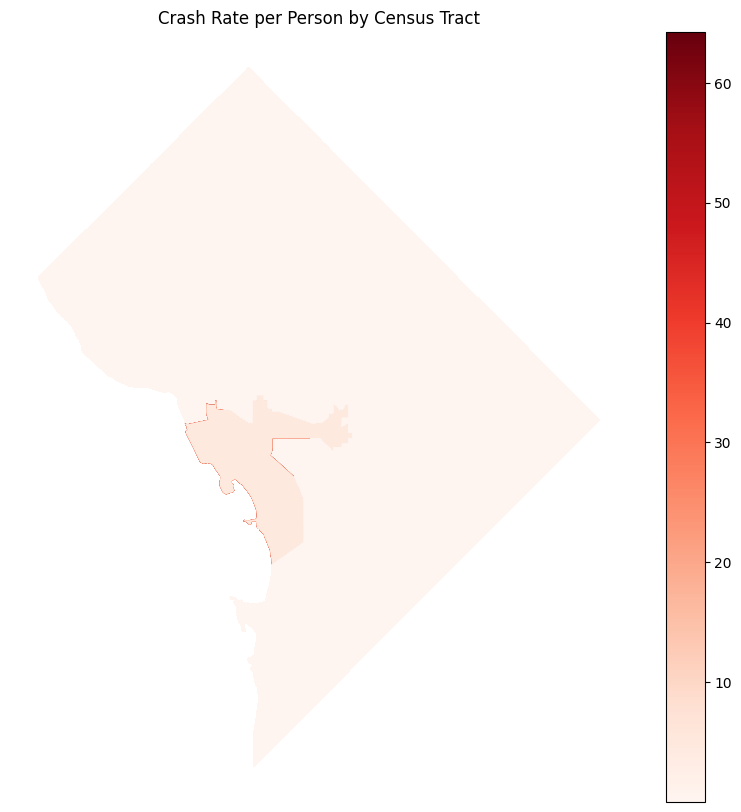

In [36]:
# Map crash rate

import matplotlib.pyplot as plt

panel.plot(column="crash_rate", cmap="Reds", legend=True, figsize=(10, 10))
plt.title("Crash Rate per Person by Census Tract")
plt.axis("off")


(np.float64(-8586103.452769881),
 np.float64(-8560343.824840533),
 np.float64(4690411.100645898),
 np.float64(4722537.8465839885))

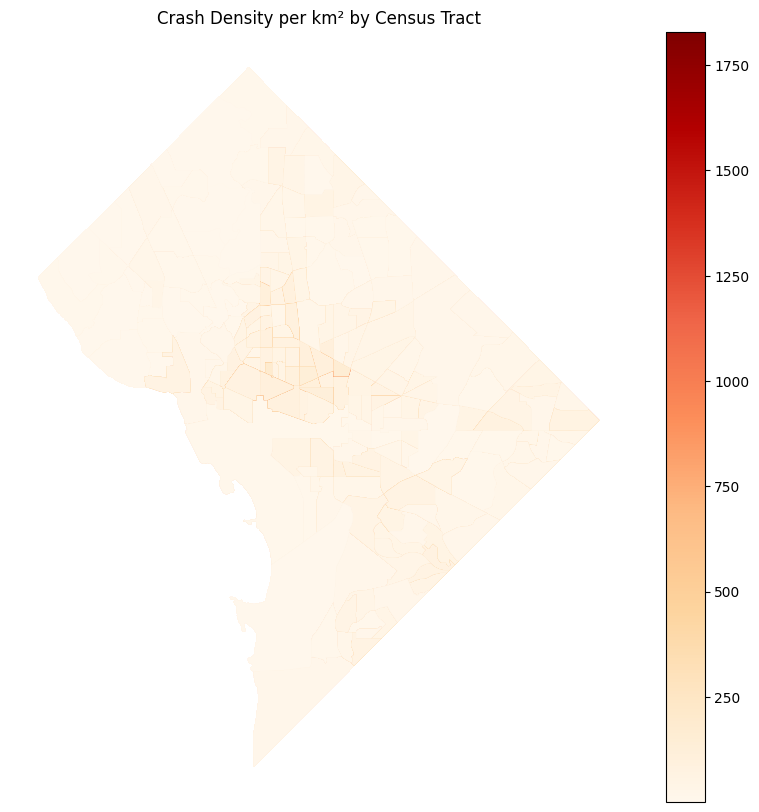

In [37]:
# Map crash density
panel.plot(column="crash_density", cmap="OrRd", legend=True, figsize=(10, 10))
plt.title("Crash Density per km² by Census Tract")
plt.axis("off")


This chart below helps answer:
Do more signals → more crashes?  
(Or are signals placed where crashes already happen?)

Text(0.5, 1.0, 'Signal Density vs Crash Count')

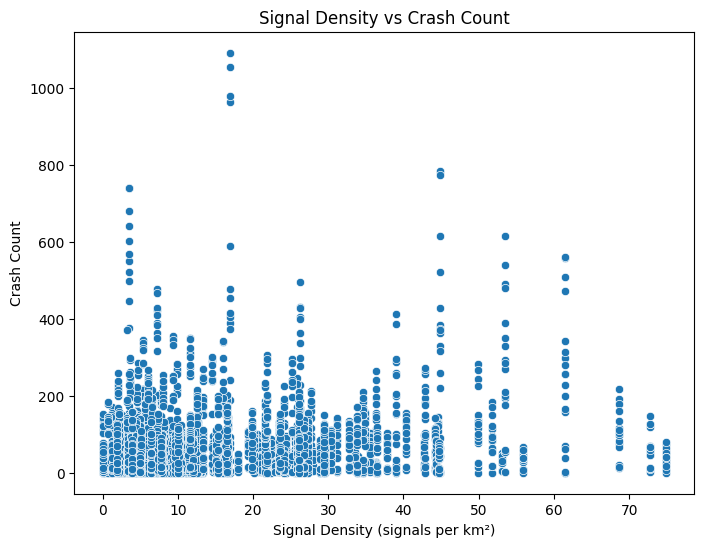

In [39]:
# Scatter Plot — Signals vs Crashes
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=panel,
    x=panel["signal_count"] / panel["area_km2"],
    y="crash_count"
)
plt.xlabel("Signal Density (signals per km²)")
plt.ylabel("Crash Count")
plt.title("Signal Density vs Crash Count")


Text(0.5, 1.0, 'Race Composition vs Crash Risk')

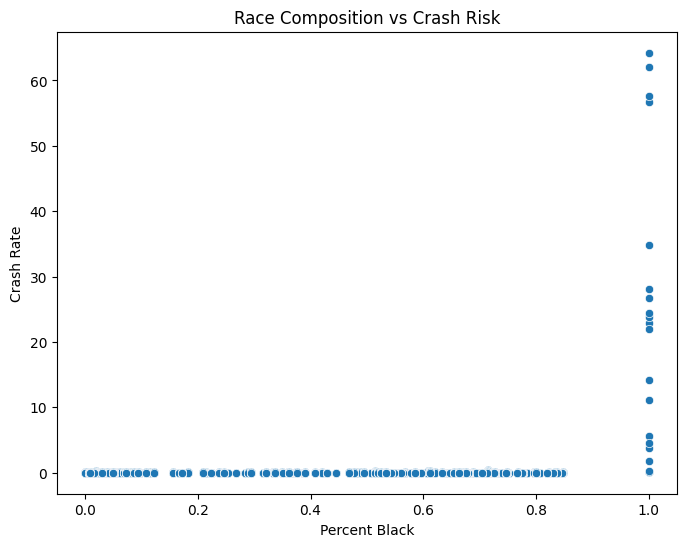

In [42]:
# Scatter Plot — Demographics vs Crash Risk

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=panel,
    x="pct_black",
    y="crash_rate"
)
plt.xlabel("Percent Black")
plt.ylabel("Crash Rate")
plt.title("Race Composition vs Crash Risk")




Text(0.5, 1.0, 'Hispanic Population vs Crash Risk')

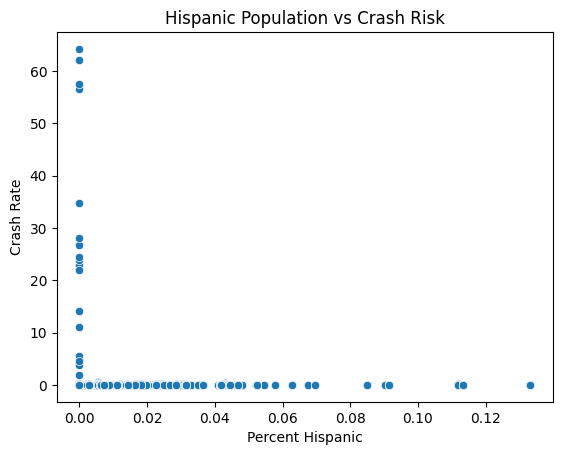

In [43]:
sns.scatterplot(
    data=panel,
    x="pct_hispanic",
    y="crash_rate"
)
plt.xlabel("Percent Hispanic")
plt.ylabel("Crash Rate")
plt.title("Hispanic Population vs Crash Risk")


Identifying “Silent High‑Risk” Tracts.

These are tracts with:

low crash counts

high crash rate or density

In [44]:
panel["risk_score"] = (
    0.5 * panel["crash_rate"] +
    0.5 * panel["crash_density"]
)

high_risk_low_count = panel[
    (panel["crash_count"] < panel["crash_count"].median()) &
    (panel["risk_score"] > panel["risk_score"].median())
]


(np.float64(-8586103.452769881),
 np.float64(-8560343.824840533),
 np.float64(4690411.100645898),
 np.float64(4722537.8465839885))

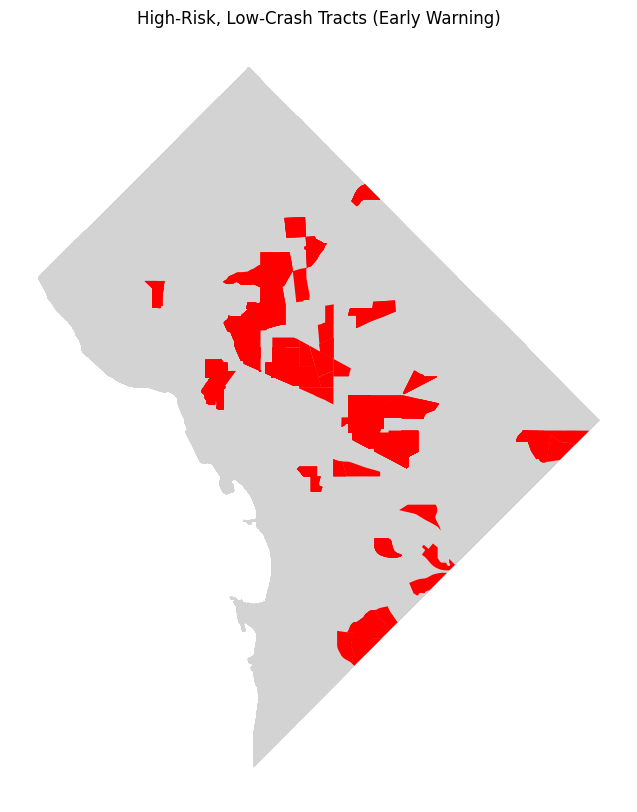

In [45]:
# mapping
base = panel.plot(color="lightgrey", figsize=(10,10))
high_risk_low_count.plot(ax=base, color="red")
plt.title("High-Risk, Low-Crash Tracts (Early Warning)")
plt.axis("off")


Text(0.5, 1.0, 'Correlation Matrix')

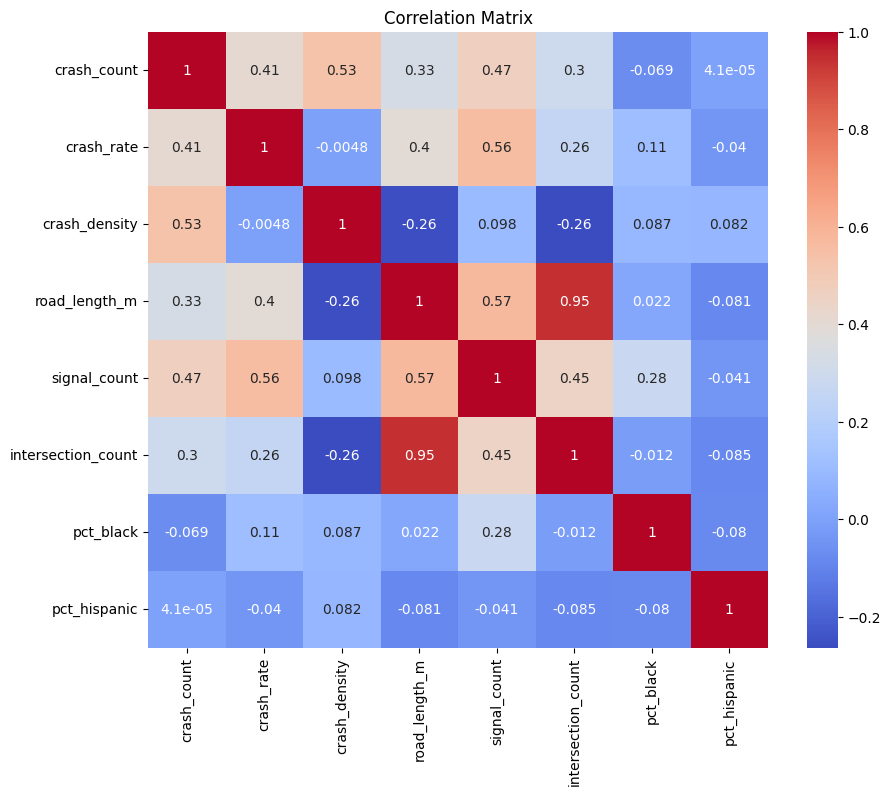

In [46]:
# Correlation Matrix
corr = panel[[
    "crash_count",
    "crash_rate",
    "crash_density",
    "road_length_m",
    "signal_count",
    "intersection_count",
    "pct_black",
    "pct_hispanic"
]].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
